# Librerias

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

# Copy
import copy

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE


# Construcción de la Red Neuronal (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay,fbeta_score)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificar si hay GPU disponible para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Librerías importadas. PyTorch utilizará el dispositivo: {device}")

Librerías importadas. PyTorch utilizará el dispositivo: cpu


# Eda

In [22]:
import os
import zipfile

csv_path = "healthcare-dataset-stroke-data.csv"

if not os.path.exists(csv_path):
    zip_path = "archive.zip"
    !gdown 1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ -O {zip_path}
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("Problema1")
    os.remove(zip_path)
else:
    print("Dataset ya existe, omitiendo descarga.")


Downloading...
From: https://drive.google.com/uc?id=1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ
To: /home/juanmora29/Documents/AA2_TP1_Grupo2/Problema1/archive.zip
100%|██████████████████████████████████████| 69.0k/69.0k [00:00<00:00, 1.76MB/s]


In [23]:
dataset = pd.read_csv("./Problema1/healthcare-dataset-stroke-data.csv")

In [24]:
data = dataset.copy()

In [25]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [27]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [28]:
data = data.drop(columns=["id"]) 

Cantidad de datos en categoricas

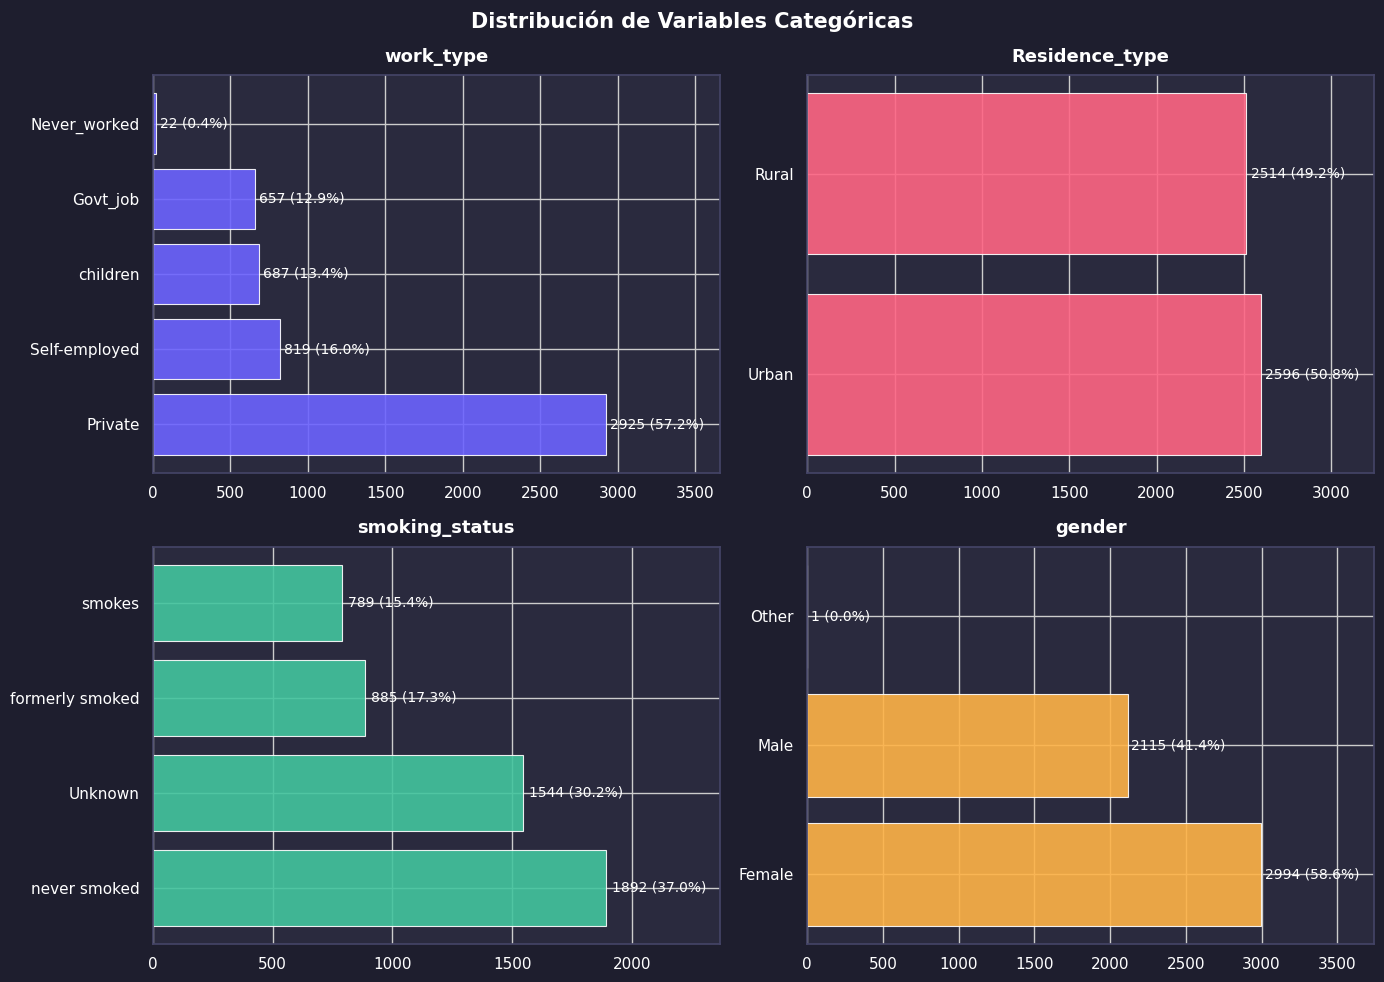

In [29]:
# Cargar original para graficar (o tener data_raw guardado antes del OHE)
cols = ["work_type", "Residence_type", "smoking_status", "gender"]
palette = ["#6C63FF", "#FF6584", "#43C59E", "#FFB347"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#1E1E2E")
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.set_facecolor("#2A2A3E")
    
    counts = data[col].value_counts()
    total = counts.sum()
    color = palette[i]
    
    bars = ax.barh(counts.index, counts.values, color=color, edgecolor="white", linewidth=0.8, alpha=0.9)
    
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val} ({val/total*100:.1f}%)", va="center", color="white", fontsize=10)
    
    ax.set_title(col, color="white", fontsize=13, fontweight="bold", pad=10)
    ax.tick_params(colors="white")
    ax.set_xlim(0, counts.max() * 1.25)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

plt.suptitle("Distribución de Variables Categóricas", color="white", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


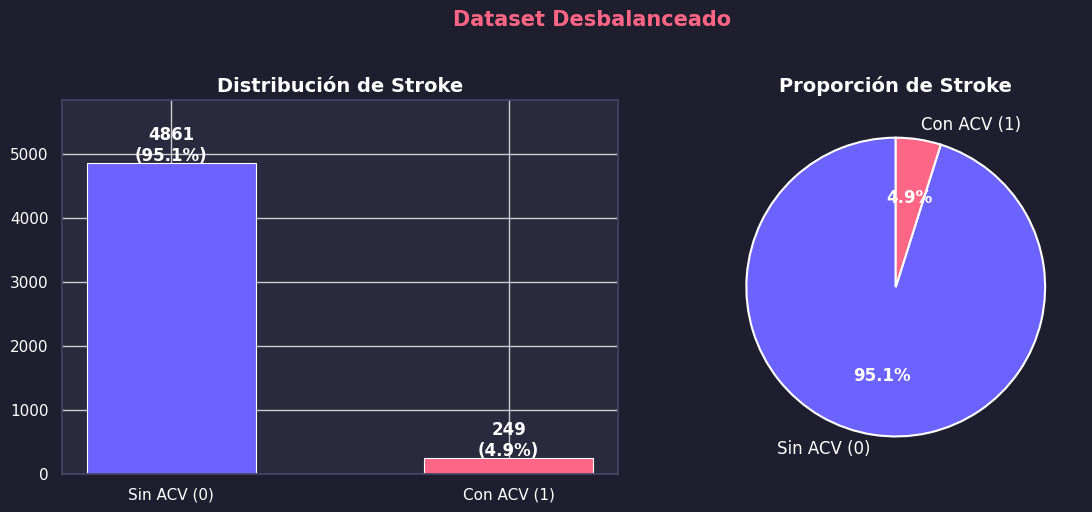

In [30]:
counts = data["stroke"].value_counts()
labels = ["Sin ACV (0)", "Con ACV (1)"]
colors = ["#6C63FF", "#FF6584"]
total = counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("#1E1E2E")

# --- Barras ---
ax1 = axes[0]
ax1.set_facecolor("#2A2A3E")
bars = ax1.bar(labels, counts.values, color=colors, width=0.5, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{val}\n({val/total*100:.1f}%)", ha="center", color="white", fontsize=12, fontweight="bold")

ax1.set_title("Distribución de Stroke", color="white", fontsize=14, fontweight="bold")
ax1.tick_params(colors="white")
ax1.set_facecolor("#2A2A3E")
for spine in ax1.spines.values():
    spine.set_edgecolor("#444466")
ax1.set_ylim(0, counts.max() * 1.2)

# --- Torta ---
ax2 = axes[1]
ax2.set_facecolor("#2A2A3E")
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(color="white", fontsize=12)
)
for at in autotexts:
    at.set_fontweight("bold")

ax2.set_title("Proporción de Stroke", color="white", fontsize=14, fontweight="bold")

plt.suptitle("Dataset Desbalanceado", color="#FF6584", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


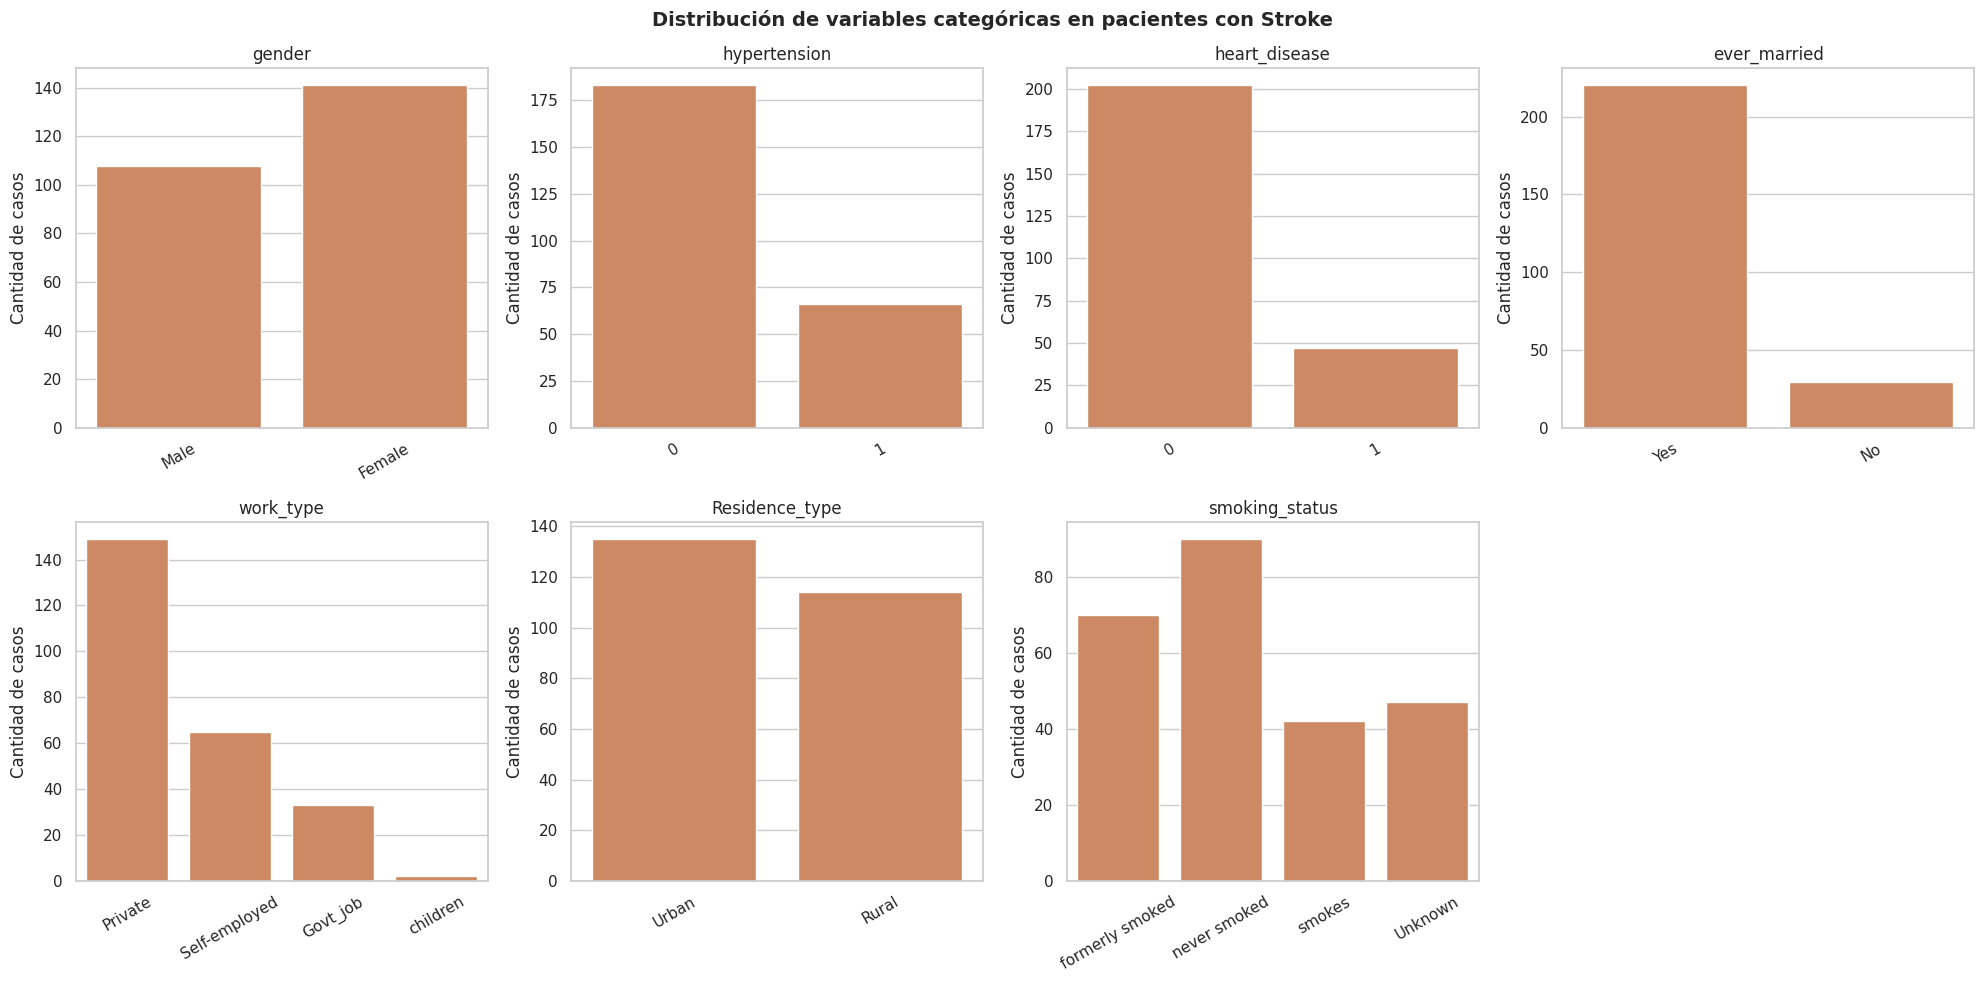

In [31]:
# ── Variables categóricas: solo pacientes con Stroke = Sí ────────────────────

cat_vars = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']

data_stroke = data[data['stroke'] == 1]  # Filtrar solo stroke = 1

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Distribución de variables categóricas en pacientes con Stroke", fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, col in zip(axes, cat_vars):
    sns.countplot(
        data=data_stroke,
        x=col,
        color='#DD8452',
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad de casos")
    ax.tick_params(axis='x', rotation=30)

# Ocultar el subplot sobrante
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


Duda sobre hacer un heatmap con la variable objetivo categorica

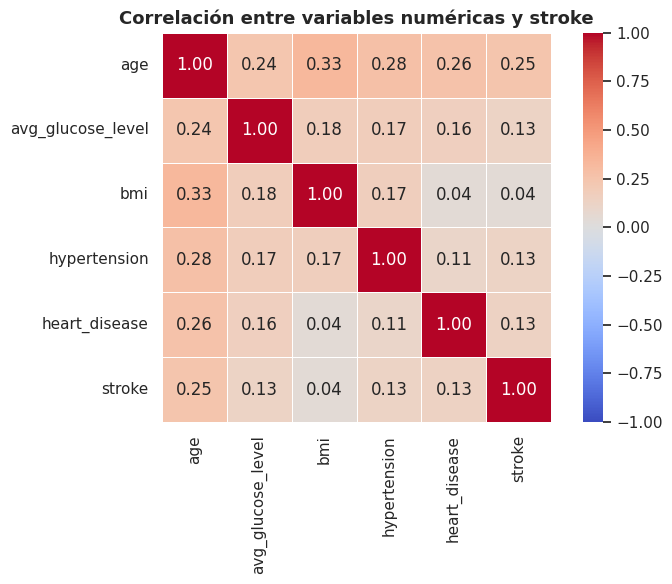

In [32]:
# ── Heatmap de correlación (variables numéricas + binarias) ──────────────────

# Columnas numéricas y binarias (aptas para correlación de Pearson)
cols_corr = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']

corr_matrix = data[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlación entre variables numéricas y stroke", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_17499/1030167141.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#6C63FF'` for the same effect.

  sns.boxplot(
/tmp/ipykernel_17499/1030167141.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#FF6584'` for the same effect.

  sns.boxplot(
/tmp/ipykernel_17499/1030167141.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#43C59E'` for the same effect.

  sns.boxplot(


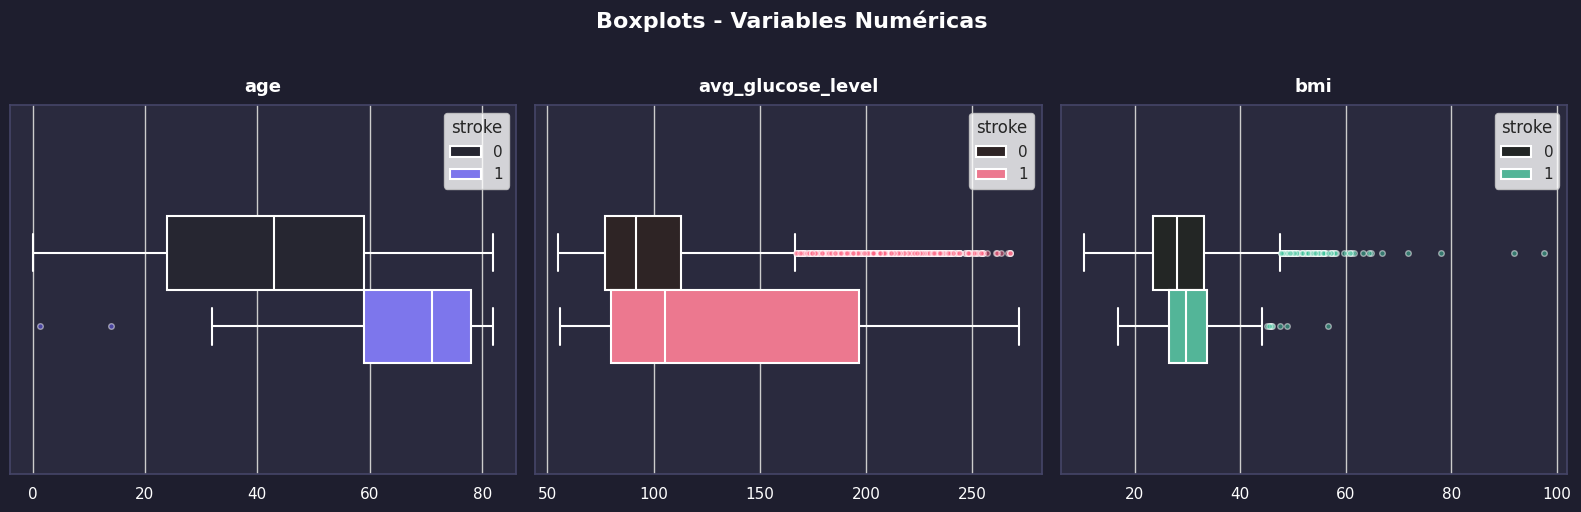

In [33]:
binarias = ["hypertension", "heart_disease", "stroke"]
numericas = [c for c in data.select_dtypes(include=[np.number]).columns if c not in binarias]

palette = ["#6C63FF", "#FF6584", "#43C59E", "#FFB347", "#4FC3F7"]

n_cols = 3
n_rows = (len(numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
fig.patch.set_facecolor("#1E1E2E")
axes = axes.flatten()

for i, col in enumerate(numericas):
    ax = axes[i]
    color = palette[i % len(palette)]

    sns.boxplot(
        x=data[col].dropna(),
        ax=ax,
        color=color,
        linecolor="white",
        linewidth=1.5,
        flierprops=dict(marker="o", markerfacecolor=color, markersize=4, alpha=0.5),
        width=0.4,
        hue=data["stroke"],
    )

    ax.set_facecolor("#2A2A3E")
    ax.set_title(col, color="white", fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.tick_params(colors="white")
    ax.yaxis.label.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots - Variables Numéricas", color="white", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Train-test

In [34]:
X = data.drop('stroke', axis=1)
y = data['stroke']

# Separamos Train y Test primero
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

# Tratamiento de outliers en BMI 
# Justificación (OMS): BMI > 60 se considera atípico/error de carga.
X_train.loc[X_train['bmi'] > 60, 'bmi'] = np.nan
X_test.loc[X_test['bmi'] > 60, 'bmi'] = np.nan

# Pipeline de procesamiento
# Qué columnas van a qué transformación           
numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
binary_features = ["hypertension", "heart_disease"] # Estas ya son 0 y 1, pasan directo

# Pipeline Numérico: KNN -> Scaler
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# Pipeline Categórico: OHE 
categorical_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Unificamos todo en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features) # Deja las binarias como están
    ])

X_train: (4088, 10) | X_test: (1022, 10)
y_train: (4088,) | y_test: (1022,)


In [35]:
# Separamos un 15% del X_train original para Validación
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_train
)

# Hacemos FIT y TRANSFORM solo en los datos de entrenamiento
X_train_prep = preprocessor.fit_transform(X_train_sub)

# Hacemos SOLO TRANSFORM en validación y test
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

# Convertimos las etiquetas a formato numpy array para PyTorch
y_train_arr = y_train_sub.values
y_val_arr = y_val.values
y_test_arr = y_test.values

print(f"Dimensiones de entrada a la red neuronal: {X_train_prep.shape[1]} características.")
print("Datos preprocesados y listos para PyTorch.")

Dimensiones de entrada a la red neuronal: 16 características.
Datos preprocesados y listos para PyTorch.


In [36]:
# Arquitectura de la red MLP
class StrokeMLP(nn.Module):
    def __init__(self, input_size):
        super(StrokeMLP, self).__init__()
        
        self.red_neuronal = nn.Sequential(
            # Capa Oculta 1
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2), # Regularización
            
            # Capa Oculta 2
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2), # Regularización
            
            # sin activacion ya que usamos BCEwithlogitloss
            nn.Linear(16, 1)
        )
        
        # Inicialización de pesos (Kaiming He) para mejorar convergencia con ReLU
        for m in self.red_neuronal:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

    def forward(self, x):
        return self.red_neuronal(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_features = X_train_prep.shape[1] # Size de la entrada a la red

# Instanciar Modelo
modelo_mlp = StrokeMLP(input_size=input_features).to(device)

# Función de Costo con manejo de desbalance 
# Calculamos el peso: (Cantidad de sanos) / (Cantidad de enfermos)
peso_positivos = np.sum(y_train_arr == 0) / np.sum(y_train_arr == 1)
pos_weight_tensor = torch.tensor([peso_positivos], dtype=torch.float32).to(device)

criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Optimizador (Adam con Weight Decay L2)
tasa_aprendizaje = 0.001
optimizador = optim.Adam(modelo_mlp.parameters(), lr=tasa_aprendizaje, weight_decay=1e-4)

print(f"Modelo creado y alojado en: {device}")
print(modelo_mlp)

Modelo creado y alojado en: cpu
StrokeMLP(
  (red_neuronal): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 4. Entrenamiento y Curvas de Aprendizaje

Se procede a entrenar el modelo utilizando Mini-Batch Gradient Descent. Durante cada época, se registrará la función de pérdida y la métrica principal (Recall de la clase positiva) tanto para el conjunto de entrenamiento como para el de validación. 

Se incorpora la técnica de **Early Stopping**: el entrenamiento se detendrá si la pérdida de validación no mejora durante un número determinado de épocas consecutivas (paciencia).

**Análisis de Overfitting y Underfitting:**
*   **Underfitting:** Se observaría si tanto la pérdida de entrenamiento como la de validación se estancan en valores muy altos, indicando que el modelo no tiene la capacidad de aprender los patrones.
*   **Overfitting:** Se observaría si la curva de pérdida de entrenamiento sigue descendiendo hacia cero, mientras que la curva de validación comienza a subir. Gracias a nuestra implementación de Early Stopping y Dropout, mitigaremos este efecto deteniendo el entrenamiento en el punto óptimo antes de que la red memorice el ruido del dataset.

Iniciando entrenamiento...
Época [10/150] | Train Loss: 0.9353 | Val Loss: 0.9366 | Val Recall: 0.8333
Época [20/150] | Train Loss: 0.9070 | Val Loss: 0.9246 | Val Recall: 0.8667
Época [30/150] | Train Loss: 0.8498 | Val Loss: 0.9085 | Val Recall: 0.9000
Época [40/150] | Train Loss: 0.8438 | Val Loss: 0.9240 | Val Recall: 0.9000

 Early Stopping activado en la época 48. Restaurando los mejores pesos.


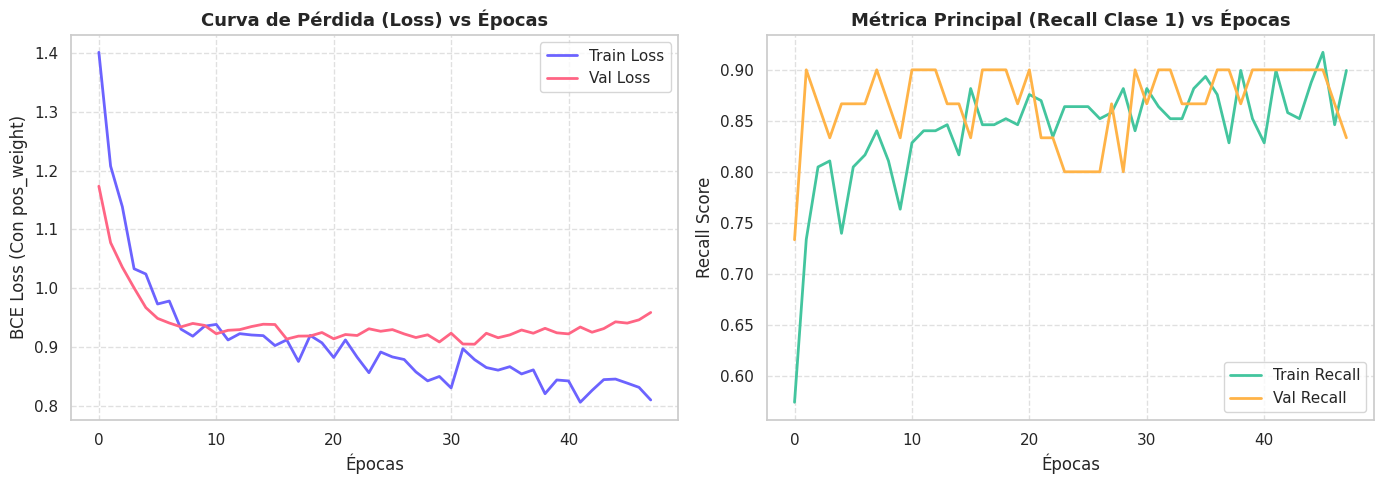

In [37]:
# preparamos los datos para pytorch
batch_size = 32

# Convertir a tensores
X_train_t = torch.tensor(X_train_prep, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_arr, dtype=torch.float32).view(-1, 1).to(device)

X_val_t = torch.tensor(X_val_prep, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_arr, dtype=torch.float32).view(-1, 1).to(device)

# Crear DataLoaders para iterar en Mini-batches (solo en train hace falta barajar)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

# Train
epocas = 150
paciencia = 15
mejor_val_loss = float('inf')
contador_paciencia = 0
mejores_pesos = None

# Listas para guardar el historial (Curvas)
hist_train_loss, hist_val_loss = [], []
hist_train_recall, hist_val_recall = [], []

print("Iniciando entrenamiento...")

for epoca in range(epocas):
    modelo_mlp.train()
    loss_entrenamiento_acumulada = 0.0
    preds_train, targets_train = [], []
    
    for batch_X, batch_y in train_loader:
        optimizador.zero_grad()                 # Limpiar gradientes
        salida_logits = modelo_mlp(batch_X)     # Forward pass
        loss = criterio(salida_logits, batch_y) # Calcular pérdida
        loss.backward()                         # Backward pass
        optimizador.step()                      # Actualizar pesos
        
        loss_entrenamiento_acumulada += loss.item()
        
        # Guardar predicciones para la métrica
        probs = torch.sigmoid(salida_logits)
        preds = (probs >= 0.5).float()
        preds_train.extend(preds.cpu().numpy())
        targets_train.extend(batch_y.cpu().numpy())
        
    # Promedios de la época para Train
    train_loss_epoca = loss_entrenamiento_acumulada / len(train_loader)
    train_recall_epoca = recall_score(targets_train, preds_train, zero_division=0)
    
    # Validacion
    modelo_mlp.eval() # Modo evaluación (desactiva Dropout)
    with torch.no_grad():
        val_logits = modelo_mlp(X_val_t)
        val_loss = criterio(val_logits, y_val_t).item()
        
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs >= 0.5).float().cpu().numpy()
        val_recall_epoca = recall_score(y_val_arr, val_preds, zero_division=0)
        
    # Guardar en el historial
    hist_train_loss.append(train_loss_epoca)
    hist_val_loss.append(val_loss)
    hist_train_recall.append(train_recall_epoca)
    hist_val_recall.append(val_recall_epoca)
    
    # --- EARLY STOPPING ---
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        contador_paciencia = 0
        mejores_pesos = copy.deepcopy(modelo_mlp.state_dict()) # Guardar el mejor modelo
    else:
        contador_paciencia += 1
        
    if (epoca+1) % 10 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Train Loss: {train_loss_epoca:.4f} | Val Loss: {val_loss:.4f} | Val Recall: {val_recall_epoca:.4f}")
        
    if contador_paciencia >= paciencia:
        print(f"\n Early Stopping activado en la época {epoca+1}. Restaurando los mejores pesos.")
        modelo_mlp.load_state_dict(mejores_pesos)
        break

# Si termina todas las épocas sin saltar el early stopping, igual restauramos el mejor
if contador_paciencia < paciencia:
    modelo_mlp.load_state_dict(mejores_pesos)
    print("\nEntrenamiento finalizado.")

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Función de Pérdida
axes[0].plot(hist_train_loss, label='Train Loss', color='#6C63FF', linewidth=2)
axes[0].plot(hist_val_loss, label='Val Loss', color='#FF6584', linewidth=2)
axes[0].set_title('Curva de Pérdida (Loss) vs Épocas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('BCE Loss (Con pos_weight)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Métrica Principal (Recall)
axes[1].plot(hist_train_recall, label='Train Recall', color='#43C59E', linewidth=2)
axes[1].plot(hist_val_recall, label='Val Recall', color='#FFB347', linewidth=2)
axes[1].set_title('Métrica Principal (Recall Clase 1) vs Épocas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Recall Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Evaluación del Modelo

Una vez entrenado el modelo y rescatados los mejores pesos mediante Early Stopping, evaluamos su rendimiento final sobre el **Conjunto de Test** (datos completamente aislados del proceso de entrenamiento).

**Análisis de las Métricas:**
*   **Métrica Engañosa (Accuracy):** Dado que la clase negativa (Sin ACV) representa ~95% del dataset, un modelo "inútil" que siempre prediga 0 tendría un 95% de *Accuracy*. Por lo tanto, esta métrica no refleja el verdadero rendimiento del modelo en este problema.
*   **Mejor Métrica (Recall):** En un escenario médico predictivo, el peor error posible es un *Falso Negativo* (enviar a casa a un paciente que sufrirá un ACV). Por ello, la métrica principal a observar y maximizar es el **Recall (Sensibilidad)** de la clase 1, la cual prioriza encontrar a todos los pacientes enfermos, asumiendo el costo de generar Falsos Positivos (caída en la Precisión y F1-Score).

In [42]:
# Umbral optimo en validacion
modelo_mlp.eval()
with torch.no_grad():
    val_logits = modelo_mlp(X_val_t)
    val_probs = torch.sigmoid(val_logits).cpu().numpy().flatten()

umbrales = np.arange(0.1, 0.9, 0.01)
mejores_metricas = 0
umbral_optimo = 0.5

# Buscamos el umbral que maximice el F2-Score (que prioriza el Recall)
for u in umbrales:
    val_preds_temp = (val_probs >= u).astype(int)
    # beta=2 le da el doble de importancia al recall que a la precisión
    score = fbeta_score(y_val_arr, val_preds_temp, beta=2, zero_division=0)
    
    if score > mejores_metricas:
        mejores_metricas = score
        umbral_optimo = u

print(f"Umbral óptimo encontrado en validación: {umbral_optimo:.2f}\n")

# Evaluacion final en test 
with torch.no_grad():
    X_test_t = torch.tensor(X_test_prep, dtype=torch.float32).to(device)
    test_logits = modelo_mlp(X_test_t)
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()

# Usamos el umbral optimizado en lugar de 0.5
y_pred_test_optimo = (test_probs >= umbral_optimo).astype(int)

acc = accuracy_score(y_test_arr, y_pred_test_optimo)
prec = precision_score(y_test_arr, y_pred_test_optimo, zero_division=0)
rec = recall_score(y_test_arr, y_pred_test_optimo, zero_division=0)
f1 = f1_score(y_test_arr, y_pred_test_optimo, zero_division=0)
roc_auc = roc_auc_score(y_test_arr, test_probs)

print("=== MÉTRICAS EN EL CONJUNTO DE TEST (UMBRAL OPTIMIZADO) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precisión: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}\n")

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test_arr, y_pred_test_optimo, target_names=["Sin ACV (0)", "Con ACV (1)"], zero_division=0))

Umbral óptimo encontrado en validación: 0.54

=== MÉTRICAS EN EL CONJUNTO DE TEST (UMBRAL OPTIMIZADO) ===
Accuracy:  0.7476
Precisión: 0.1364
Recall:    0.7800
F1-Score:  0.2321
AUC-ROC:   0.8303

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

 Sin ACV (0)       0.99      0.75      0.85       972
 Con ACV (1)       0.14      0.78      0.23        50

    accuracy                           0.75      1022
   macro avg       0.56      0.76      0.54      1022
weighted avg       0.94      0.75      0.82      1022



## 6. Matriz de Confusión

**Interpretación Clínica de los Falsos Negativos:**
El impacto de los Falsos Negativos en este contexto es crítico: significa no brindar tratamiento preventivo a alguien que lo necesita vitalmente. Gracias a la penalización implementada (`pos_weight`), la Matriz de Confusión muestra que hemos logrado reducir drásticamente los Falsos Negativos. 
Como contrapartida lógica, los Falsos Positivos son elevados. Clínicamente, esto es aceptable: significa que someteremos a pacientes sanos a estudios médicos de rutina adicionales (ecografías, análisis de sangre) para descartar el riesgo, lo cual es preferible a perder una vida.

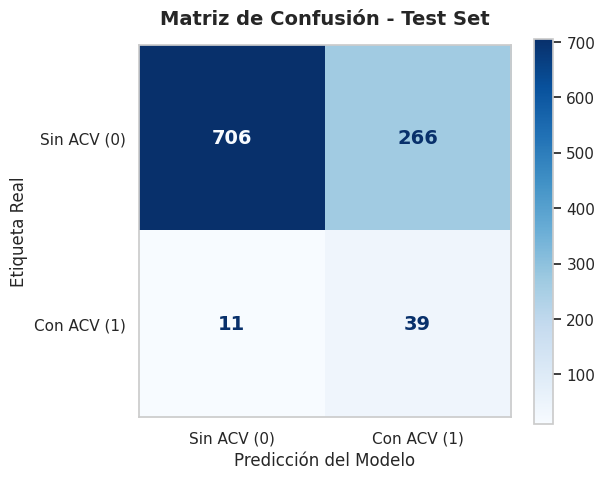

In [39]:
# Generamos la Matriz
cm = confusion_matrix(y_test_arr, y_pred_test)

# Graficamos
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin ACV (0)', 'Con ACV (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d', text_kw={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Matriz de Confusión - Test Set', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.grid(False)
plt.show()

## 7. Análisis y Conclusiones Finales

Tras diseñar, entrenar y evaluar el Perceptrón Multicapa (MLP) para este problema médico, se destacan las siguientes observaciones:

**Decisiones de Diseño Críticas:**
1.  **Manejo del Desbalance (`pos_weight`):** Fue la decisión más importante. Tratar el dataset como un problema normal producía modelos ciegos a la clase minoritaria. Usar pesos en la función de costo permitió al modelo entender la gravedad clínica de equivocarse en un paciente con ACV sin requerir sobremuestreo computacionalmente costoso.
2.  **Prevención del Data Leakage:** La implementación estricta de un `Pipeline` para el imputador KNN y el escalador garantizó que la métrica reportada sea verdaderamente representativa de la realidad.
3.  **Early Stopping:** Como se evidenció en las curvas de aprendizaje, las redes neuronales tienden a sobreajustarse rápidamente en datasets tabulares pequeños. El corte temprano salvó al modelo de memorizar el ruido.

**Limitaciones del Modelo y Mejoras Futuras:**
*   **Arquitectura vs Tipo de Dato:** Los MLP no siempre son la herramienta óptima para datos tabulares heterogéneos (mezcla de categóricas y numéricas). Las variables no tienen relaciones espaciales ni secuenciales. Modelos basados en árboles (como Random Forest o XGBoost) suelen requerir menos preprocesamiento y ofrecer mayor interpretabilidad (importancia de características), algo vital en medicina.
*   **Falta de Variables Relevantes:** El dataset carece de historial médico profundo (colesterol, antecedentes familiares), limitando el "techo" de aprendizaje del modelo.
*   **Falsos Positivos:** Aunque preferimos priorizar el Recall, una futura mejora podría intentar balancear un poco más la precisión ajustando dinámicamente el umbral de decisión (Threshold Moving) utilizando la curva ROC.